<a href="https://colab.research.google.com/github/hemalatha092005-wq/DBSCAN/blob/main/DBSCAN_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
os.environ['KAGGLE_USERNAME']="HEMA HEMA"
os.environ['KAGGLE_KEY']="KGAT_0c5cc0dcae69341f803b98fd5272d09e"

In [ ]:
!kaggle datasets download -d ankit8467/dataset-for-dbscan

Dataset URL: https://www.kaggle.com/datasets/ankit8467/dataset-for-dbscan
License(s): unknown
100% 39.3k/39.3k [00:00<00:00, 31.3MB/s]



In [ ]:
import os
import zipfile
#path to your zip file
zip_path="/content/dataset-for-dbscan.zip"
extract_path="extracted_files"
#create folder if not extists
os.makedirs(extract_path, exist_ok=True)

#extract all files
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
  zip_ref.extractall(extract_path)

print(" Files extracted to:", extract_path)

 Files extracted to: extracted_files


In [ ]:
#Step 1:Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors


In [ ]:
#step 2: Load Dataset
data = pd.read_csv("/content/extracted_files/Clustering_gmm (2).csv")
print("First 5 rows:", data.head())

First 5 rows:       Weight      Height
0  67.062924  176.086355
1  68.804094  178.388669
2  60.930863  170.284496
3  59.733843  168.691992
4  65.431230  173.763679


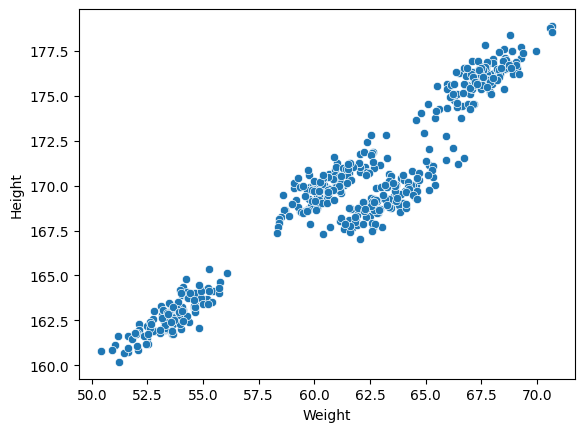

In [ ]:
sns.scatterplot(data=data, x="Weight", y="Height")
plt.show()

In [ ]:
# -------------------------------
# 1. Data Preprocessing
# -------------------------------

# Handle Missing Values
print("\nMissing values:\n", data.isnull().sum())
data = data.dropna()   # drop rows with nulls


Missing values:
 Weight    0
Height    0
dtype: int64


In [ ]:
# Feature Selection (only numerical features)
X = data[['Weight','Height']]

In [ ]:
# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
# -------------------------------
# 2. Determine Hyperparameters
# -------------------------------

# Rule of thumb: MinPts >= D+1 (here D=2 → MinPts=3 or more)
min_samples = 4

In [ ]:
# Plot K-Distance Graph to find eps
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

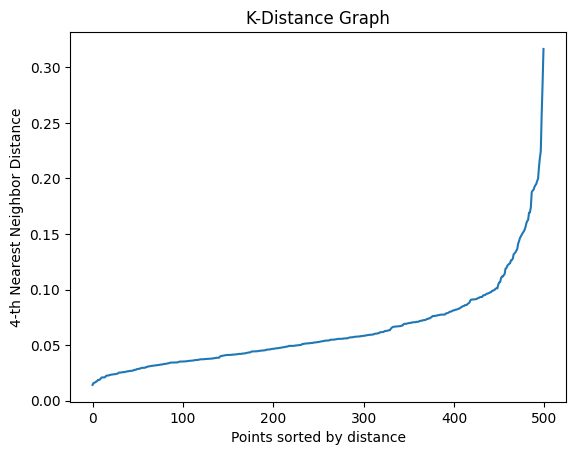

In [ ]:
# Sort distances to visualize knee/elbow
distances = np.sort(distances[:,min_samples-1])
plt.plot(distances)
plt.title("K-Distance Graph")
plt.xlabel("Points sorted by distance")
plt.ylabel(f"{min_samples}-th Nearest Neighbor Distance")
plt.show()

In [ ]:
eps = 0.17# chosen from elbow in k-distance graph
min_samples = 4
db = DBSCAN(eps=eps, min_samples=min_samples)
labels = db.fit_predict(X_scaled)


In [ ]:
# Add cluster labels to dataset
data['Cluster'] = labels
print("\nClustered data sample:\n", data.head())


Clustered data sample:
       Weight      Height  Cluster
0  67.062924  176.086355        0
1  68.804094  178.388669        0
2  60.930863  170.284496        1
3  59.733843  168.691992        1
4  65.431230  173.763679        0


In [ ]:
# -------------------------------
# 4. Evaluation and Insights
# -------------------------------

# Identify Noise
noise_points = sum(labels == -1)
print("\nNoise points:", noise_points)


Noise points: 5


In [ ]:
# Count Clusters (excluding noise)
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
print("Number of clusters:", n_clusters)

Number of clusters: 3


In [ ]:
# Silhouette Score (only if >1 cluster and minimal noise)
if n_clusters > 1:
    sil_score = silhouette_score(X_scaled[labels != -1], labels[labels != -1])
    print("Silhouette Score:", sil_score)

Silhouette Score: 0.73727116109947


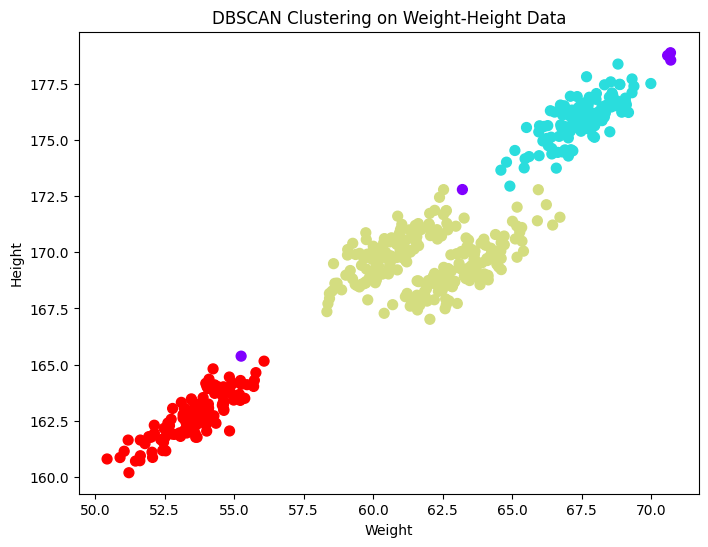

In [ ]:
# Visualization
plt.figure(figsize=(8,6))
plt.scatter(data['Weight'], data['Height'], c=data['Cluster'], cmap='rainbow', s=50)
plt.xlabel("Weight")
plt.ylabel("Height")
plt.title("DBSCAN Clustering on Weight-Height Data")
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


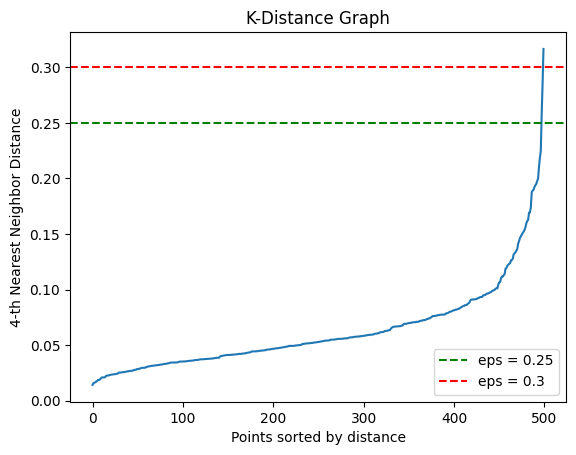

In [ ]:
# distances already sorted

plt.plot(distances)
plt.title("K-Distance Graph")
plt.xlabel("Points sorted by distance")
plt.ylabel(f"{min_samples}-th Nearest Neighbor Distance")

# Highlight region between 0.25 and 0.3
plt.axhline(y=0.25, color='g', linestyle='--', label='eps = 0.25')
plt.axhline(y=0.3, color='r', linestyle='--', label='eps = 0.3')

plt.legend()
plt.show()